# 04. EDA·상관계수·PCA

입력: 03번이 저장한 병합·정규화 CSV와 행정동 경계.

출력: 행정동 지도 4개, 상관계수 그림 및 표, PCA 설명 분산·성분.

ZIP에 입력 CSV를 포함했으므로 이 노트북부터 열어 볼 수도 있습니다.

각 노트북은 별도 커널에서 실행할 수 있습니다. 공유 변수는 사용하지 않고 파일로 입력을 읽습니다. ZIP에는 기존 실행 결과도 들어 있습니다.

In [1]:
from pathlib import Path
import sys
# Supports Jupyter launched from the repository root or notebooks/.
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src' / 'paths.py').exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError('저장소 폴더 또는 notebooks 폴더에서 노트북을 실행하세요.')
sys.path.insert(0, str(PROJECT_ROOT))
from src.paths import ROOT, data_path, result_path

# 필요 시 주석 해제
# %pip install -r requirements.txt
from IPython.display import Image, HTML, display


In [2]:
"""PDF 기반 재구현. 원본 코드 복원이 아니며 설정/선정 규칙은 새로 명시했다."""
from pathlib import Path
import ast, json, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import cdist
import folium
SEED = 42
PREDICTION_SOURCE = 'saved'
COMMERCIAL_DATASET = 'historical_2022'  # official_2025 선택 가능
COUNTS_SOURCE = 'saved'  # saved: 기존 집계 / rebuilt: 좌표 결과의 재집계
N_CLUSTERS = 3
REMOVE_OUTLIERS = False
OUTLIER_QUANTILE = 0.95
TARGET_DONG = '송천1동'  # PDF의 상세 분석 대상. 새 군집 결과와 별도로 명시

### `read_csv`

In [3]:
def read_csv(name):
    for enc in ('utf-8-sig', 'cp949'):
        try:
            return pd.read_csv(data_path(name), encoding=enc, low_memory=False).dropna(how='all')
        except UnicodeDecodeError:
            continue
    raise ValueError(f'인코딩 확인 필요: {name}')

### `numeric`

In [4]:
def numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(',', '', regex=False), errors='coerce')

### `save_csv`

In [5]:
def save_csv(df, name):
    df.to_csv(result_path(name), index=False, encoding='utf-8-sig')

### `clean_dong`

In [6]:
def clean_dong(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    if s.startswith('['):
        try:
            vals = ast.literal_eval(s)
            s = str(vals[0]) if vals else ''
        except (ValueError, SyntaxError):
            return None
    s = s.split()[-1] if s.split() else ''
    if s.lower() in ('nan', 'none', ''):
        return None
    return s

### `grouped_counts`

In [7]:
def grouped_counts(name, count_name):
    d = read_csv(name)
    d['행정동'] = d['ADDRESS'].map(clean_dong)
    audit = d[d['행정동'].isna()]
    save_csv(audit, name.replace('.csv', '_unmatched.csv'))
    return d.dropna(subset=['행정동']).groupby('행정동').size().rename(count_name).reset_index()

### `correlation_plot`

In [8]:
def correlation_plot(frame, cols, filename):
    corr = frame[cols].corr()
    save_csv(corr.rename_axis('feature').reset_index(), filename.replace('.png','.csv'))
    fig,ax = plt.subplots(figsize=(7,6))
    im=ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm')
    ax.set_xticks(range(len(cols)),[f'F{i+1}' for i in range(len(cols))])
    ax.set_yticks(range(len(cols)),[f'F{i+1}' for i in range(len(cols))])
    for i in range(len(cols)):
        for j in range(len(cols)): ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center')
    fig.colorbar(im,ax=ax);fig.tight_layout();fig.savefig(result_path(filename),dpi=160);plt.close(fig)
    save_csv(pd.DataFrame({'axis_label':[f'F{i+1}' for i in range(len(cols))],'feature':cols}),filename.replace('.png','_legend.csv'))

### `load_geojson`

In [9]:
def load_geojson():
    geo=json.loads((data_path('hangjeongdong_전라북도.geojson')).read_text())
    geo['features']=[f for f in geo['features'] if '전주시' in f['properties']['adm_nm']]
    for f in geo['features']:f['properties']['dong']=clean_dong(f['properties']['adm_nm'])
    return geo

### `eda`

In [10]:
def eda(raw, scaled, features):
    geo=load_geojson()
    for i,c in enumerate(features+['인구수']):
        m=folium.Map(tiles='OpenStreetMap.HOT', location=[35.824223,127.147953],zoom_start=11)
        folium.Choropleth(geo_data=geo,data=raw,columns=['행정동',c],key_on='feature.properties.dong',
                        fill_color='YlGn',legend_name=c,nan_fill_color='gray').add_to(m)
        vals=raw.set_index('행정동')[c].to_dict()
        for f in geo['features']: f['properties']['value']=float(vals.get(f['properties']['dong'],np.nan))
        folium.GeoJson(geo,tooltip=folium.GeoJsonTooltip(fields=['dong','value'])).add_to(m)
        m.save(str(result_path(f'eda_{i+1}.html')))
    correlation_plot(raw,features+['인구수'],'correlation_before.png')
    # PDF와 같이 인구수를 제외. 인과 관계/독립성 증명을 의미하지 않음.
    correlation_plot(raw,features,'correlation_after.png')
    X=scaled[features].to_numpy()
    pca=PCA().fit(X)
    save_csv(pd.DataFrame({'component':np.arange(1,4),'explained_ratio':pca.explained_variance_ratio_,
                           'cumulative_ratio':np.cumsum(pca.explained_variance_ratio_)}),'pca_variance.csv')
    save_csv(pd.DataFrame(pca.components_,columns=features).rename_axis('component').reset_index(),'pca_loadings.csv')
    fig,ax=plt.subplots();ax.plot(range(1,4),np.cumsum(pca.explained_variance_ratio_),'o-')
    ax.set(xlabel='Number of components',ylabel='Cumulative explained variance',xticks=[1,2,3])
    fig.tight_layout();fig.savefig(result_path('pca.png'),dpi=160);plt.close(fig)
    return X

## 저장된 입력 불러오기

In [11]:
required = ['merged_raw.csv', 'scaled_rebuilt.csv']
for name in required:
    if not result_path(name).exists():
        raise FileNotFoundError(f'{name}가 없습니다. 03_merge_normalize.ipynb를 먼저 실행하세요.')
raw = pd.read_csv(result_path('merged_raw.csv'))
scaled = pd.read_csv(result_path('scaled_rebuilt.csv'))
features = ['원룸 및 주택 밀집', '쓰레기 민원 빈도', '연간 쓰레기 배출량 예측 값']


## EDA 및 PCA 실행

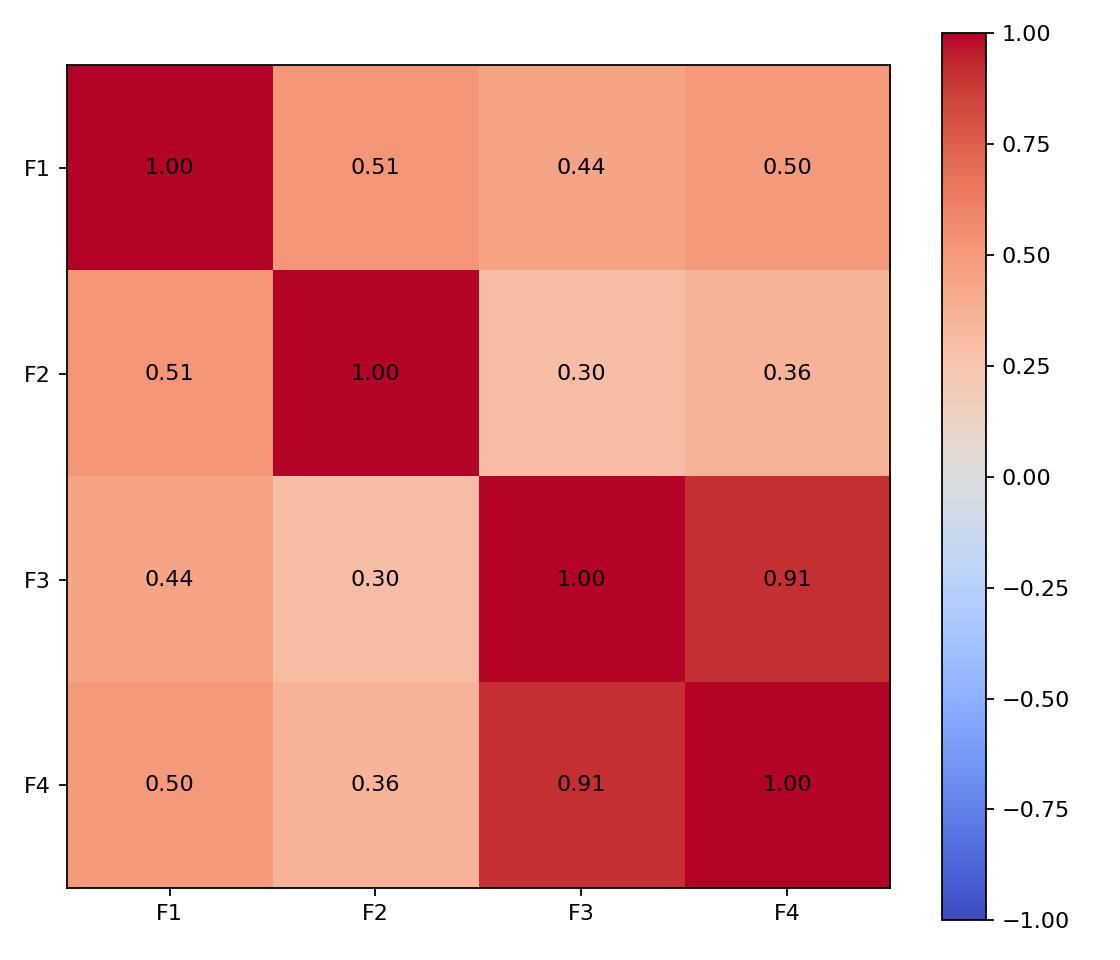

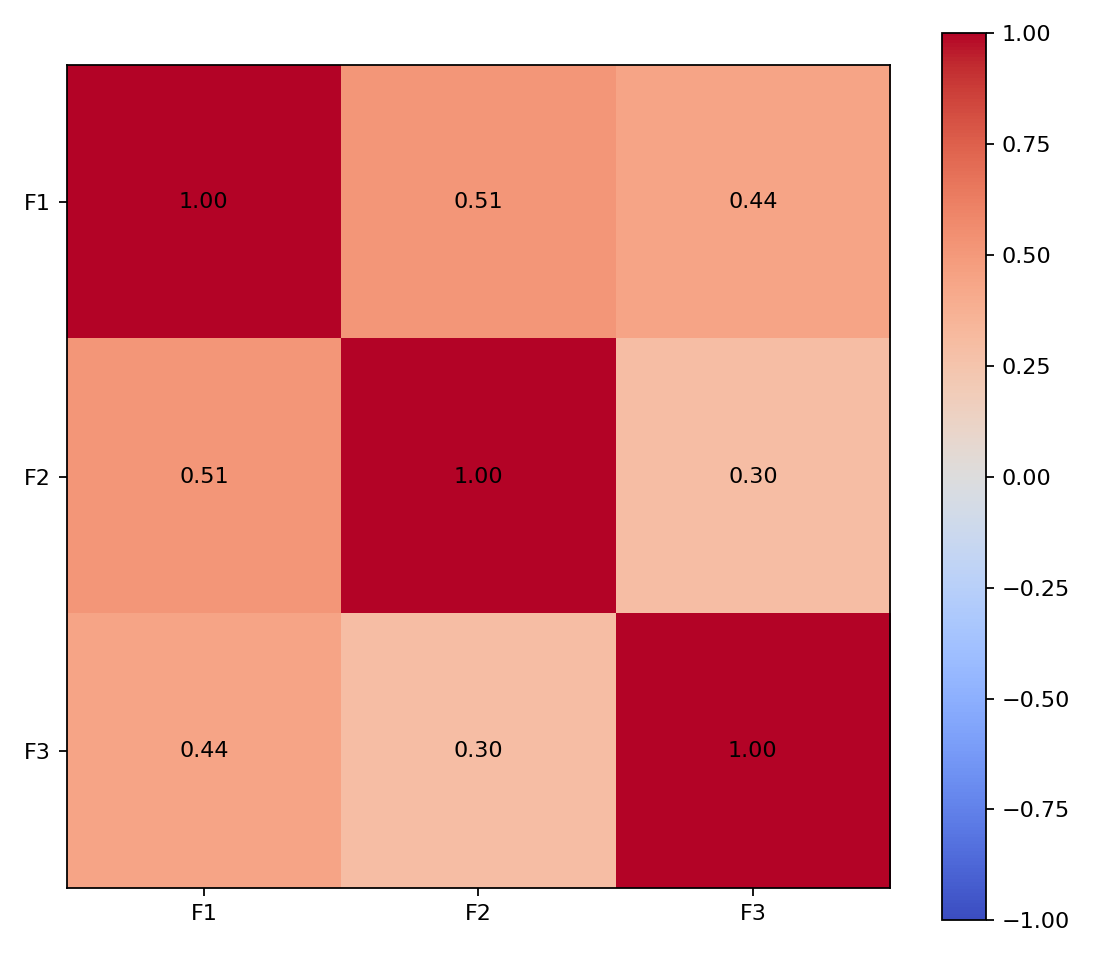

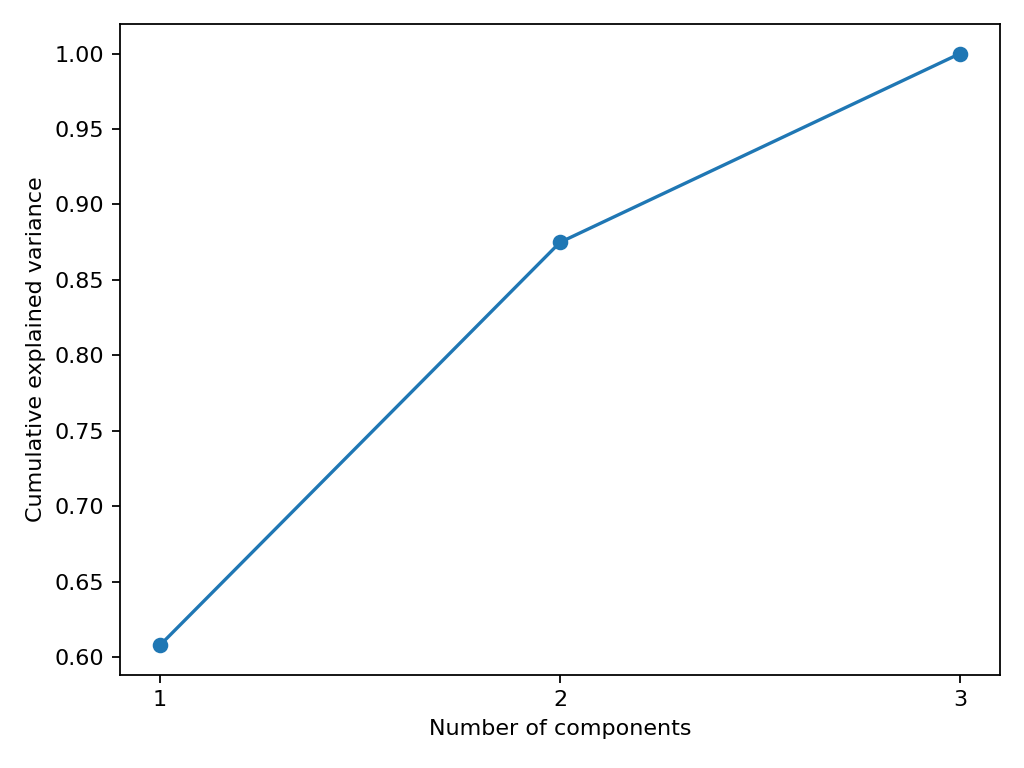

,component,explained_ratio,cumulative_ratio
0,1,0.607904,0.607904
1,2,0.266991,0.874895
2,3,0.125105,1.000000


In [12]:
X = eda(raw, scaled, features)
display(Image(filename=str(result_path('correlation_before.png'))))
display(Image(filename=str(result_path('correlation_after.png'))))
display(Image(filename=str(result_path('pca.png'))))
display(pd.read_csv(result_path('pca_variance.csv')))
display(HTML(result_path('eda_1.html').read_text(encoding='utf-8')))